 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Sebastian Szmytka                <br>
Student Number : L 00196514        <br>
Due Date       : 12th May 2359hrs                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs

## Imports

In [42]:
# imports basics + text and analysis
import os
import spacy
from spacy import displacy
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
import cv2
import pytesseract
from pytesseract import Output
import pymupdf
import sys
import re
print(sys.executable)
from sklearn.feature_extraction.text import TfidfVectorizer

# imports for CV
from matplotlib import pyplot as plt
import cv2
import numpy as np



/Library/Frameworks/Python.framework/Versions/3.12/bin/python3


In [3]:
# test
print("cv2", cv2.__version__)
print("pytesseract", pytesseract.__version__)

cv2 4.13.0
pytesseract 0.3.13


# Support Functions

In [19]:
# Support functions
def create_lemmatization(text_to_convert):
    text_to_convert = nlp(text_to_convert)
    for token in text_to_convert:
        print (f"{token.text:{15}} {token.lemma_:{30}}")

def create_tokenize(text_token):
    nlp = spacy.load("en_core_web_sm")
    text_token = nlp(text_token)
    for token in text_token:
        print (token.text, token.pos_, end = " | ")

    print("\n\n Number of tokens: ", len(nlp_sentence))

def check_fileformat(filepath):
    """
    function to validate file format example if its an image or a pdf file
    1. checks if file exists
    2. identify the extention
    3. make decision based on the file format and process it
    """

    if not os.path.isfile(filepath):
        return f"Error: file not found: {filepath}"

    fileextension = os.path.splitext(filepath)[1].lower()

    print(fileextension)

    try:
        if fileextension == '.pdf':
            print("file type: ", fileextension)
            return pdf_tostring(filepath)
        elif fileextension in [".bmp",".jpg",".png",".tiff",".jpeg"]:
            print("file type: ", fileextension)
            return image_tostring(filepath)
        else:
            print("Unsupported format: ", fileextension)

    except Exception as e:
        return f"An error occurred: {e}"

def image_tostring(img):
    """
    image to string function + image to boxes
    """
    print(f"\n image_tostring received: '{img}'")  
    print(f"\n repr: {repr(img)}")                 
    
    img = cv2.imread(img)
    if img is None:
        return f"Error: could not read image"
    
    h, w, c = img.shape
    print(img.shape)

    # draw bounding boxes around detected characters
    boxes = pytesseract.image_to_boxes(img)
    for i in boxes.splitlines():
        i = i.split(' ')
        img = cv2.rectangle(img, (int(i[1]), h - int(i[2])), (int(i[3]), h - int(i[4])), (0, 255, 0), 2) 
        
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Convert image to string
    custom_config = r'--oem 1 --psm 6' 
    txt = pytesseract.image_to_string(img, config=custom_config)
    print(txt)
    return txt
    
def pdf_tostring(pdf):
    """
    pdf to string function convers pdf to png file
    returns string/text
    """
    doc = pymupdf.open(pdf)
    st = ""
    output_folder = "samples/png_outputs/"
    os.makedirs(output_folder, exist_ok=True)
    # if the pdf has multiple pages this for loop can be edited to accommodate
    for page in doc:
        # setting the dpi to 200 for higher quality image - this can be set higher
        img = page.get_pixmap(dpi=300)
        #Saving the image to local drive where it can be accessed again
        path = os.path.join(output_folder, f"pdf{page.number}.png")
        print("\n Saving to path: ", path)
        print("\n Path type: ", type(path))
        img.save(path)

        print("\n File exists after save: " ,os.path.isfile(path))
        
        txt = image_tostring(path)
        
        #adding txt to one final string
        st += txt
    return st

def ImgKeyFeatures(sampleimg):
     
     """
     Function to suport section 3 of the CA2 NLP - Detectand recognize key featuresin both the text and images:
     - tables
     - signatures
     - diagrams
     - figures     
     """

     print(sampleimg)

     
        
        

        
    

    
    


# NLP

## Text Extraction end Processing (OCR)


 Current Directory: /Users/sebszmytka/GIT_NLP/ca2-assignment-lightarchivist-1

.pdf
file type:  .pdf

 Saving to path:  samples/png_outputs/pdf0.png

 Path type:  <class 'str'>

 File exists after save:  True

 image_tostring received: 'samples/png_outputs/pdf0.png'

 repr: 'samples/png_outputs/pdf0.png'
(3300, 2550, 3)


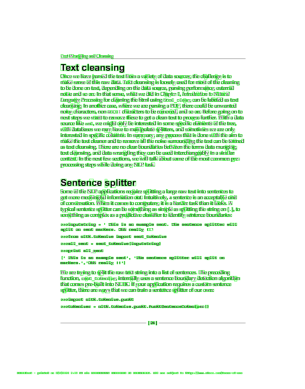

Deh Worf ling arid Heong)

Text cleansing

Othce we have jpansed) the text fridin a waitiety, off data soumoes) the chiallerige ils fo

nike sense Of thils naw dattal. Neékt cleansing iis loosely; used fion nfiost of the clleaniing,

to be done on fext, depending) on the daital source, pansiing perfonmmamioe) exitenrial

ndise and so on lin thai sense, wiht we diid im Cliapten 1, Untrodiation to \Niztunal

Dangnegye (Processing fon ol¢aniing, the hitmil using Himil_oléan, can be labeled as text

dleariéig) lin anothen case, wihisre we ane parsing a PDF) thiene could be unwanted

noisy) Chamactens, mon ASOD CHandCtens to be rdinowed) and so om Befone going) oni fo

nexit steps we waint fo remove tthlese fo get a clean fext fo progess famthien. Wiith! a daita

sounoe like xmil, we mnikght dmly| be iintenested lin some spjicifilo eldiriénts of thie tree,

with! databases we mey) have to mainijpullate gplilitens, and) sémetiiniés we ane only,

iinfenested iin specific coltatins: In sumnany

In [25]:
## code
# test of file format function

cwd = os.getcwd()
print(f"\n Current Directory: {cwd}\n")
file1 = "KaggleDataset/images/0.jp "
file2 = "samples/pdf/TextCleansing-2.pdf"



st = check_fileformat(file2)
st_full = st

# just to make it tidier i will limit the amout of text to make the outputs cleaner

st = "\n".join(st.split("\n")[:10])

# print(st)

# print(st_full)


## Text Cleaning

### Tokenisation
segmenting sentences in to units called "tokens"

In [21]:
# tokenisation - load english language library

nlp = spacy.load("en_core_web_sm")


In [22]:
# process and show tokens
nlp_sentence = nlp(st)

for token in nlp_sentence:
    print (token.text, token.pos_, end = " | ") # sentence use and separation

# counting tokens
print("\n\n Number of tokens: ", len(nlp_sentence))

Deh PROPN | Worf PROPN | ling NOUN | arid NOUN | Heong PROPN | ) PUNCT | 

 SPACE | Text NOUN | cleansing NOUN | 

 SPACE | Othce PROPN | we PRON | have AUX | jpansed VERB | ) PUNCT | the DET | text NOUN | fridin ADP | a DET | waitiety NOUN | , PUNCT | off ADP | data NOUN | soumoes NOUN | ) PUNCT | the DET | chiallerige NOUN | ils VERB | fo ADP | 

 SPACE | nike ADJ | sense NOUN | Of SCONJ | thils VERB | naw PROPN | dattal PROPN | . PUNCT | Neékt ADJ | cleansing NOUN | iis NOUN | loosely ADV | ; PUNCT | used VERB | fion NOUN | nfiost NOUN | of ADP | the DET | clleaniing NOUN | , PUNCT | 

 SPACE | to PART | be AUX | done VERB | on ADP | fext NOUN | , PUNCT | depending VERB | ) PUNCT | on ADP | the DET | daital ADJ | source NOUN | , PUNCT | pansiing VERB | perfonmmamioe ADJ | ) PUNCT | exitenrial NOUN | 

 SPACE | ndise NOUN | and CCONJ | so ADV | on ADP | lin PROPN | thai PROPN | sense PROPN | , PUNCT | wiht ADJ | we PRON | diid VERB | i PRON | m VERB | Cliapten PROPN | 1 NUM | , PUNCT

In [23]:
# using function defined in support functions section

create_tokenize(st)

Deh PROPN | Worf PROPN | ling NOUN | arid NOUN | Heong PROPN | ) PUNCT | 

 SPACE | Text NOUN | cleansing NOUN | 

 SPACE | Othce PROPN | we PRON | have AUX | jpansed VERB | ) PUNCT | the DET | text NOUN | fridin ADP | a DET | waitiety NOUN | , PUNCT | off ADP | data NOUN | soumoes NOUN | ) PUNCT | the DET | chiallerige NOUN | ils VERB | fo ADP | 

 SPACE | nike ADJ | sense NOUN | Of SCONJ | thils VERB | naw PROPN | dattal PROPN | . PUNCT | Neékt ADJ | cleansing NOUN | iis NOUN | loosely ADV | ; PUNCT | used VERB | fion NOUN | nfiost NOUN | of ADP | the DET | clleaniing NOUN | , PUNCT | 

 SPACE | to PART | be AUX | done VERB | on ADP | fext NOUN | , PUNCT | depending VERB | ) PUNCT | on ADP | the DET | daital ADJ | source NOUN | , PUNCT | pansiing VERB | perfonmmamioe ADJ | ) PUNCT | exitenrial NOUN | 

 SPACE | ndise NOUN | and CCONJ | so ADV | on ADP | lin PROPN | thai PROPN | sense PROPN | , PUNCT | wiht ADJ | we PRON | diid VERB | i PRON | m VERB | Cliapten PROPN | 1 NUM | , PUNCT

### Stopword

In [26]:
# loading whats reqired
nltk.download('punkt_tab')

nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sebszmytka/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sebszmytka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### NLTK

In [27]:
# using NLTK

print("\n >>> stop words with NLTK \n")

st_tokens = word_tokenize(st)

tokens_without_sw = [word for word in st_tokens if not word in stopwords.words()]

print(tokens_without_sw)

print("\n",len(tokens_without_sw))


 >>> stop words with NLTK 

['Deh', 'Worf', 'ling', 'arid', 'Heong', ')', 'Text', 'cleansing', 'Othce', 'jpansed', ')', 'text', 'fridin', 'waitiety', ',', 'data', 'soumoes', ')', 'chiallerige', 'fo', 'nike', 'Of', 'thils', 'naw', 'dattal', '.', 'Neékt', 'cleansing', 'iis', 'loosely', ';', 'fion', 'nfiost', 'clleaniing', ',', 'fext', ',', 'depending', ')', 'daital', 'source', ',', 'pansiing', 'perfonmmamioe', ')', 'exitenrial']

 46


#### spaCy

In [28]:
# using spaCy

sp = spacy.load("en_core_web_sm")

sp_stopwords = sp.Defaults.stop_words

print("\n >>> stop words with spaCy for comparasment \n")

spacy_st = word_tokenize(st)

tokens_without_sw_sp =[ word for word in spacy_st if not word in sp_stopwords]

print("\n", tokens_without_sw_sp, "\n")

print("\n",len(tokens_without_sw_sp))


 >>> stop words with spaCy for comparasment 


 ['Deh', 'Worf', 'ling', 'arid', 'Heong', ')', 'Text', 'cleansing', 'Othce', 'jpansed', ')', 'text', 'fridin', 'waitiety', ',', 'data', 'soumoes', ')', 'chiallerige', 'ils', 'fo', 'nike', 'sense', 'Of', 'thils', 'naw', 'dattal', '.', 'Neékt', 'cleansing', 'iis', 'loosely', ';', 'fion', 'nfiost', 'clleaniing', ',', 'fext', ',', 'depending', ')', 'daital', 'source', ',', 'pansiing', 'perfonmmamioe', ')', 'exitenrial'] 


 48


#### larger text for comparasment

In [30]:


fulltxt = word_tokenize(st_full)
 
# NLTK
tokens_full = [word for word in fulltxt if not word in stopwords.words()]

print("\n NLTK count: ",len(tokens_full))

# spaCy

tokens_full_sp =[ word for word in fulltxt if not word in sp_stopwords]


print("\n spaCY count: ",len(tokens_full_sp))


 NLTK count:  396

 spaCY count:  419


#### Joining tokens

In [31]:
jtokens = (" ").join(tokens_without_sw)
print(jtokens)

Deh Worf ling arid Heong ) Text cleansing Othce jpansed ) text fridin waitiety , data soumoes ) chiallerige fo nike Of thils naw dattal . Neékt cleansing iis loosely ; fion nfiost clleaniing , fext , depending ) daital source , pansiing perfonmmamioe ) exitenrial


In [32]:
### adding stop words to the list

In [33]:


print("\n >> Elenents in stopword list: ",len(stopwords.words('english')), "\n") # how long is the list
print(stopwords.words('english')) # just to see whats in the list

new_stopwords = stopwords.words('english')
new_stopwords.append('NLP')

new_stopwords.append('>')

print("\n >>> New stopwords list\n")

print("Elements in new stopword list: ",len(new_stopwords), "\n")

print(new_stopwords)


 >> Elenents in stopword list:  198 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 'r

## Stemming 
extracting the root of the word  

In [34]:
porter_stemmer = PorterStemmer()
st_port = st.split() # conver to list of words

for word in st_port:
    print(word + " ------> " + porter_stemmer.stem(word))




Deh ------> deh
Worf ------> worf
ling ------> ling
arid ------> arid
Heong) ------> heong)
Text ------> text
cleansing ------> cleans
Othce ------> othc
we ------> we
have ------> have
jpansed) ------> jpansed)
the ------> the
text ------> text
fridin ------> fridin
a ------> a
waitiety, ------> waitiety,
off ------> off
data ------> data
soumoes) ------> soumoes)
the ------> the
chiallerige ------> chiallerig
ils ------> il
fo ------> fo
nike ------> nike
sense ------> sens
Of ------> of
thils ------> thil
naw ------> naw
dattal. ------> dattal.
Neékt ------> neékt
cleansing ------> cleans
iis ------> ii
loosely; ------> loosely;
used ------> use
fion ------> fion
nfiost ------> nfiost
of ------> of
the ------> the
clleaniing, ------> clleaniing,
to ------> to
be ------> be
done ------> done
on ------> on
fext, ------> fext,
depending) ------> depending)
on ------> on
the ------> the
daital ------> daital
source, ------> source,
pansiing ------> pansi
perfonmmamioe) ------> perfonmma

## Lemmatisation
compares to stemming, this is method uses gramar/actual dictionary form

In [35]:
# creating document object

document = nlp(st)

# check for tokens and associated parts-of-speech (POS) tags

for t in document:
    print(t, t.pos_)


# root words analysis

for w in document:
    print(w.text + " |---> " + w.lemma_)

# Lemmatisation versus stemming

for w in document:
    print(w.text + " |---> " + w.lemma_,"\t", w.pos_)

# using function created 

create_lemmatization(st)

# View token tags

for t in document:
    print(f"{t.text:{20}} {t.pos_:{15}}  {t.tag_:{10}} {spacy.explain(t.tag_)}")

Deh PROPN
Worf PROPN
ling NOUN
arid NOUN
Heong PROPN
) PUNCT


 SPACE
Text NOUN
cleansing NOUN


 SPACE
Othce PROPN
we PRON
have AUX
jpansed VERB
) PUNCT
the DET
text NOUN
fridin ADP
a DET
waitiety NOUN
, PUNCT
off ADP
data NOUN
soumoes NOUN
) PUNCT
the DET
chiallerige NOUN
ils VERB
fo ADP


 SPACE
nike ADJ
sense NOUN
Of SCONJ
thils VERB
naw PROPN
dattal PROPN
. PUNCT
Neékt ADJ
cleansing NOUN
iis NOUN
loosely ADV
; PUNCT
used VERB
fion NOUN
nfiost NOUN
of ADP
the DET
clleaniing NOUN
, PUNCT


 SPACE
to PART
be AUX
done VERB
on ADP
fext NOUN
, PUNCT
depending VERB
) PUNCT
on ADP
the DET
daital ADJ
source NOUN
, PUNCT
pansiing VERB
perfonmmamioe ADJ
) PUNCT
exitenrial NOUN

 SPACE
Deh |---> Deh
Worf |---> Worf
ling |---> ling
arid |---> arid
Heong |---> Heong
) |---> )


 |---> 


Text |---> text
cleansing |---> cleansing


 |---> 


Othce |---> Othce
we |---> we
have |---> have
jpansed |---> jpanse
) |---> )
the |---> the
text |---> text
fridin |---> fridin
a |---> a
waitiety |---> wait

In [36]:
# POS Tags 

print("\n >>> spaCy predicting the use of tokens in the sentence and can also find is verb is present or past tense \n")

for t in document:
    print(f" {t.text:{10}} {t.pos_:{10}} {t.tag_:{10}} {spacy.explain(t.tag_):{20}}")

print("\n >>> filtered option for one word \n")

print(f"{document[6].text:{10}} {document[6].pos_:{10}} {document[6].tag_:{10}} {spacy.explain(document[6].tag_):{20}}")

print("\n >>> POS Tag Frequency\n")
fcount = document.count_by(spacy.attrs.POS)
print("\n", fcount, "\n") 

print("\nLooking up ID of the POS tag 100: \n")
document.vocab[100].text

print("\n >>> POS Count Frequency is an disctionary, so checking in:  \n")

for i, fr in fcount.items():
    print(f" {i:{10}} {document.vocab[i].text:{10}} {fr}")

print("\n >>> For more details output we can use spacy.attrs.TAG: \n")

finegrainedPOS = document.count_by(spacy.attrs.TAG)

for i, fr in sorted (finegrainedPOS.items()):
    print(f" {i:{20}} {document.vocab[i].text:{10}} {fr}")

print("\n >>> Visualization of POS tags using displacy module: \n")

displacy.render(document, style='dep', jupyter=True, options={'distance': 120})


 >>> spaCy predicting the use of tokens in the sentence and can also find is verb is present or past tense 

 Deh        PROPN      NNP        noun, proper singular
 Worf       PROPN      NNP        noun, proper singular
 ling       NOUN       NN         noun, singular or mass
 arid       NOUN       NN         noun, singular or mass
 Heong      PROPN      NNP        noun, proper singular
 )          PUNCT      -RRB-      right round bracket 
 

         SPACE      _SP        whitespace          
 Text       NOUN       NN         noun, singular or mass
 cleansing  NOUN       NN         noun, singular or mass
 

         SPACE      _SP        whitespace          
 Othce      PROPN      NNP        noun, proper singular
 we         PRON       PRP        pronoun, personal   
 have       AUX        VBP        verb, non-3rd person singular present
 jpansed    VERB       VBN        verb, past participle
 )          PUNCT      -RRB-      right round bracket 
 the        DET        DT         d

## Feature extraction

### TF-IDF 

word/term frequency in the document

In [43]:
vectorizer = TfidfVectorizer()

x = vectorizer.fit_transform([st])

print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 44 stored elements and shape (1, 44)>
  Coords	Values
  (0, 8)	0.11867816581938533
  (0, 43)	0.11867816581938533
  (0, 21)	0.11867816581938533
  (0, 0)	0.11867816581938533
  (0, 17)	0.11867816581938533
  (0, 36)	0.23735633163877065
  (0, 3)	0.23735633163877065
  (0, 30)	0.11867816581938533
  (0, 42)	0.11867816581938533
  (0, 16)	0.11867816581938533
  (0, 20)	0.11867816581938533
  (0, 37)	0.4747126632775413
  (0, 15)	0.11867816581938533
  (0, 41)	0.11867816581938533
  (0, 28)	0.11867816581938533
  (0, 6)	0.11867816581938533
  (0, 34)	0.11867816581938533
  (0, 2)	0.11867816581938533
  (0, 19)	0.11867816581938533
  (0, 14)	0.11867816581938533
  (0, 26)	0.11867816581938533
  (0, 33)	0.11867816581938533
  (0, 27)	0.23735633163877065
  (0, 38)	0.11867816581938533
  (0, 23)	0.11867816581938533
  (0, 7)	0.11867816581938533
  (0, 24)	0.11867816581938533
  (0, 18)	0.11867816581938533
  (0, 22)	0.11867816581938533
  (0, 40)	0.118678165

### Named Entity Recognition (NER)
predicting "real world objects" with spaCy


In [37]:
# iterating over entities found in hte document
for ent in document.ents:
    print(f"{ent.text:{30}} {ent.label_:{15}} {spacy.explain(ent.label_)}")

# Visualising NER using displacy
displacy.render(document, style='ent', jupyter=True)

Deh Worf                       PERSON          People, including fictional


### Noun Chunks
extracting meaningful noun phrases

In [38]:
for chunk in document.noun_chunks:
    print(chunk.text)

Deh Worf ling arid Heong
Othce
we
the text
a waitiety
data soumoes
the chiallerige
nike sense
naw dattal
fion nfiost
the clleaniing
fext
the daital source
perfonmmamioe) exitenrial


### Prefix / Suffix
morphological analysis

In [39]:
for t in document:
    print(f"{t.text:{20}} prefix: {t.prefix_:{10}} suffix: {t.suffix_}")

Deh                  prefix: D          suffix: Deh
Worf                 prefix: W          suffix: orf
ling                 prefix: l          suffix: ing
arid                 prefix: a          suffix: rid
Heong                prefix: H          suffix: ong
)                    prefix: )          suffix: )


                   prefix: 
          suffix: 


Text                 prefix: T          suffix: ext
cleansing            prefix: c          suffix: ing


                   prefix: 
          suffix: 


Othce                prefix: O          suffix: hce
we                   prefix: w          suffix: we
have                 prefix: h          suffix: ave
jpansed              prefix: j          suffix: sed
)                    prefix: )          suffix: )
the                  prefix: t          suffix: the
text                 prefix: t          suffix: ext
fridin               prefix: f          suffix: din
a                    prefix: a          suffix: a
waitiety             

## NLP Section Summary
The following NLP techniques were applied to the extracted text:

- **OCR Extraction**: Text was extracted from a PDF document using Tesseract OCR via PyMuPDF page rendering
- **Tokenisation**: Text was broken into individual tokens
- **Text Cleaning**:
  - **Stopword Removal**: Common words were filtered out and compared across both NLTK and spaCy stopword lists, with a custom stopword list also applied
  - **Stemming**: Porter Stemmer was applied to reduce words to their root form
  - **Lemmatisation**: spaCy was used to reduce words to their dictionary base form, preserving meaning better than stemming
- **Feature Extraction**:
  - **TF-IDF**: Term Frequency-Inverse Document Frequency scoring was applied to identify the most distinctive terms in the document
  - **NER**: Named entities were identified and categorised (persons, organisations, locations etc.)
  - **Noun Chunks**: Key noun phrases were extracted from the text
  - **Prefix/Suffix**: Morphological analysis was performed on individual tokens to examine word structure

# Vision

## Image Processing and Feature detection 

In [ ]:
# load image

testimg = 

In [ ]:
# code here...

# Multi-modal

## Multi-modal Integration and Insights

In [ ]:
# code here

# Final Output

In [ ]:
# code